In [1]:
%cd ..

/Users/danorel/Workspace/Education/University/NYU/Research/xeda


In [2]:
import chromadb
import copy
import json
import typing as t
import uuid
import pathlib

from chromadb.utils import embedding_functions
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())

from constants import (
    AWS_ACCESS_KEY_ID,
    AWS_SECRET_ACCESS_KEY,
    AWS_S3_ENDPOINT_URL,
    AWS_S3_REGION_NAME,
    AWS_S3_BUCKET_NAME,
    AWS_S3_USE_SSL,
    OPENAI_API_KEY,
    VECTOR_STORE_COLLECTION,
    VECTOR_STORE_HOST,
    VECTOR_STORE_PORT
)
from typings.pipeline import Pipeline
from pipeline.solid.pipeline_sampler import next_pipeline_iter
from utils.s3 import pull_keras_model

2024-04-05 11:44:37.885205: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
def node_to_encoding(node):
    annotation = node["annotation"]
    node_encoding = []
    for k, v in annotation.items():
        if isinstance(v, dict):
            for key in v:
                node_encoding.append(f"{k}_{key} = {v[key]}")
        else:
            node_encoding.append(f"{k} = {v}")
    return ', '.join(node_encoding)


def pipeline_to_splits(pipeline: Pipeline) -> t.List[Pipeline]:
    splits = []
    pipeline_encoding = []
    for node in reversed(pipeline):
        node_encoding = node_to_encoding(node)
        pipeline_encoding.append(node_encoding)
        splits.append(copy.deepcopy(pipeline_encoding))
    return splits


def pipeline_to_embedding(pipeline: Pipeline):
    pipeline_splits = pipeline_to_splits(pipeline)
    pipeline_payload = (
        [str(uuid.uuid4()) for _ in range(len(pipeline_splits))],
        [json.dumps(copy.deepcopy(pipeline)) for _ in range(len(pipeline_splits))],
        [';'.join(pipeline_split) for pipeline_split in pipeline_splits]
    )
    return pipeline_payload

In [4]:
pretrained_embeddings = embedding_functions.OpenAIEmbeddingFunction(
    api_key=OPENAI_API_KEY,
    model_name="text-embedding-ada-002"
)

vector_store = chromadb.HttpClient(
    host=VECTOR_STORE_HOST, 
    port=VECTOR_STORE_PORT
)

In [5]:
vector_collection = vector_store.get_collection(VECTOR_STORE_COLLECTION)

In [6]:
root_dir = pathlib.Path.cwd()

In [7]:
annotated_dir, raw_dir = (
    root_dir / "data" / "eda4sum" / "annotated",
    root_dir / "data" / "eda4sum" / "raw"
)

In [8]:
annotated_pipelines = []
for annotated_file in annotated_dir.glob('*.json'):
    with annotated_file.open('r') as f:
        annotated_pipelines.append(json.load(f))

In [9]:
for annotated_pipeline in annotated_pipelines:
    (
        pipeline_ids,
        pipeline_documents,
        pipeline_sentences
    ) = pipeline_to_embedding(annotated_pipeline)
    vector_collection.add(
        ids=pipeline_ids,
        documents=pipeline_documents,
        embeddings=pretrained_embeddings(pipeline_sentences),
    )

In [10]:
pipeline_collection = vector_collection.get()

In [11]:
pipeline_collection.keys()

dict_keys(['ids', 'embeddings', 'metadatas', 'documents', 'data', 'uris'])

In [12]:
import s3fs

from dagster import EnvVar
from pipeline.resources import S3FSResource

fs = s3fs.S3FileSystem(
    key=AWS_ACCESS_KEY_ID,
    secret=AWS_SECRET_ACCESS_KEY,
    endpoint_url=AWS_S3_ENDPOINT_URL,
    use_ssl=AWS_S3_USE_SSL,
    client_kwargs={"region_name": AWS_S3_REGION_NAME},
)

# TODO: Change policy to universal / generalized one from the EDA UI
POLICY_NAME = "policy_0f2049f5-3807-4db4-9707-ea08a6d35383_concentrated"

In [13]:
!pip install --quiet scikit-learn

In [14]:
import random
import pandas as pd
import numpy as np

from tqdm import tqdm

from pipeline.solid.utils.model_manager import ModelManager
from pipeline.solid.utils.pipelines.pipeline_precalculated_sets import PipelineWithPrecalculatedSets
from sklearn.metrics.pairwise import cosine_similarity
from typings.pipeline import RequestData

def select_attributes(pipeline):
    return f"{[node['operator'] for node in pipeline]}"

def explore_pipeline(partial_pipeline: Pipeline, database_pipeline_cache, k: int):
    # This is a stub to simulate pipeline exploration.
    # In a real scenario, this would involve applying transformations or decisions based on an RL model.
    model_manager = ModelManager(database_pipeline_cache["galaxies"], models = {
        "set": pull_keras_model(
            s3fs=fs,
            bucket_name=AWS_S3_BUCKET_NAME,
            policy_name=POLICY_NAME,
            model_name="set_actor",
        ),
        "operation": pull_keras_model(
            s3fs=fs,
            bucket_name=AWS_S3_BUCKET_NAME,
            policy_name=POLICY_NAME,
            model_name="operation_actor",
        ),
        "set_op_counters": None,
    })

    partial_latest_node = partial_pipeline[-1]
    partial_latest_request_data = partial_latest_node.get("requestData")
    
    terminal_request_data = RequestData(**partial_latest_request_data)
    terminal_pipeline = partial_pipeline.copy()
    
    for i in range(len(partial_pipeline), len(partial_pipeline) + k):
        try:
            terminal_node, terminal_request_data = next_pipeline_iter(
                database_pipeline_cache,
                model_manager,
                terminal_request_data
            )
            terminal_pipeline.append(terminal_node)
        except ValueError:
            print(f"Unexpectedly exited from pipeline generation on step {i}. Saving pipeline as it is...")
            break
    
    return terminal_pipeline


def cosine(vector_a, vector_b):
    # dot_product = np.dot(vector_a, vector_b)
    # norm_a = np.linalg.norm(vector_a)
    # norm_b = np.linalg.norm(vector_b)
    # cosine_similarity = dot_product / (norm_a * norm_b)
    # return cosine_similarity
    mean_similarity = cosine_similarity(vector_a, vector_b).mean()
    return 1 - mean_similarity


def make_experiment(pipeline_index: int, database_pipeline_cache, k: int, verbose: bool = False):

    ids  = pipeline_collection['ids']
    docs = pipeline_collection['documents']

    partial_pipeline_id   = ids[pipeline_index]
    partial_pipeline = json.loads(docs[pipeline_index])
    
    rest_pipeline_ids = ids[:pipeline_index] + ids[pipeline_index+1:]
    rest_pipelines = [json.loads(doc) for doc in docs[:pipeline_index] + docs[pipeline_index+1:]]
    
    (
        partial_pipeline_ids,
        partial_pipeline_documents,
        partial_pipeline_sentences
    ) = pipeline_to_embedding(partial_pipeline)
    
    partial_annotation_embedding = pretrained_embeddings(partial_pipeline_sentences)
    partial_response = vector_collection.query(
        query_embeddings=partial_annotation_embedding,
        n_results=len(rest_pipeline_ids),
        include=["distances", "documents"]
    )
    
    terminal_pipeline = explore_pipeline(partial_pipeline, database_pipeline_cache, k=k)
    (
        terminal_pipeline_ids,
        terminal_pipeline_documents,
        terminal_pipeline_sentences
    ) = pipeline_to_embedding(partial_pipeline)
    terminal_annotation_embedding = pretrained_embeddings(terminal_pipeline_sentences)
    
    if verbose:
        print(f"Terminal pipeline: {select_attributes(partial_pipeline)}\n")

    partial_explanation_pipelines = partial_response['documents'][0]

    min_explanation_pipeline, max_explanation_pipeline = (
        json.loads(partial_explanation_pipelines[0]),
        json.loads(partial_explanation_pipelines[-1])
    )

    if verbose:
        print(f"Min pipeline: {min_explanation_distance}%, {select_attributes(min_explanation_pipeline)}")
        print(f"Max pipeline: {max_explanation_distance}%, {select_attributes(max_explanation_pipeline)}\n")

    (
        min_pipeline_ids,
        min_pipeline_documents,
        min_pipeline_sentences
    ) = pipeline_to_embedding(min_explanation_pipeline)
    min_annotation_embedding = pretrained_embeddings(min_pipeline_sentences)

    (
        max_pipeline_ids,
        max_pipeline_documents,
        max_pipeline_sentences
    ) = pipeline_to_embedding(max_explanation_pipeline)
    max_annotation_embedding = pretrained_embeddings(max_pipeline_sentences)

    return {
        "partial_pipeline_id": partial_pipeline_id,
        "min_to_terminal_similarity": cosine(min_annotation_embedding, terminal_annotation_embedding),
        "max_to_terminal_similarity": cosine(max_annotation_embedding, terminal_annotation_embedding),
    }

def run_experiments(n: int = 1000, k: int = 5):
    measurements = pd.DataFrame()
    used_pipeline_ids = set()

    database_pipeline_cache = {}
    database_pipeline_cache["galaxies"] = PipelineWithPrecalculatedSets(
        "sdss",
        ["galaxies"],
        discrete_categories_count=10,
        min_set_size=10,
        exploration_columns=[
            "galaxies.u",
            "galaxies.g",
            "galaxies.r",
            "galaxies.i",
            "galaxies.z",
            "galaxies.petroRad_r",
            "galaxies.redshift",
        ],
        id_column="galaxies.objID",
    )

    for experiment in tqdm(range(n)):

        trial = 0
        target_pipeline_index, target_pipeline_id = None, None
        while (target_pipeline_id not in used_pipeline_ids):
            trial += 1
            print(f"Trial {trial}-th to sample {experiment + 1}-th partial pipeline within not seen pipelines")
            (
                target_pipeline_index,
                target_pipeline_id
            ) = random.sample(list(enumerate(pipeline_collection['ids'])), k=1)[0]
            if target_pipeline_id is not None:
                used_pipeline_ids.add(target_pipeline_id)
        
        measurements = pd.concat([
            measurements,
            pd.DataFrame([{
                "experiment": experiment,
                **make_experiment(target_pipeline_index, database_pipeline_cache, k=k, verbose=False)
            }])
        ])

        print(f"Recored a measurement for {experiment + 1}-th sample {target_pipeline_id}")

    return measurements

In [18]:
# TODO: More experiments.
EXPERIMENTS = 1

# TODO: Other types of similarity.
TYPES_OF_SIMILARITY = ['euclidian', 'cosine', 'manhattan']

# TODO: Plot from 3 to 10 for instance.
K = 5

# TODO: Make a demo how UI with explanation works.

In [19]:
experiments_df = run_experiments(n=EXPERIMENTS, k=K)

  0%|                                                                                                                    | 0/1 [00:00<?, ?it/s]

Trial 1-th to sample 1-th partial pipeline within not seen pipelines
1/1 [==============================] - 0s 307ms/step
[0.06291454 0.06032396 0.05923535 0.15096668 0.11207605 0.19907398
 0.03183361 0.05444521 0.15011053 0.11902009]
[0.14121705409294644, 0.13540227326859852, 0.1329587980863204, 0.3388576007344763, 0.2515642738176583, 0.0, 0.0, 0.0, 0.0, 0.0]
1/1 [==============================] - 0s 338ms/step
[0.03824119 0.05086677 0.04511657 0.04638046 0.04175233 0.17357454
 0.07962775 0.07801259 0.01628212 0.06891202 0.0747974  0.11602237
 0.05022685 0.06824071 0.02343599 0.02851032]
[0.0720660825094438, 0.09585915630215124, 0.0, 0.0, 0.0, 0.0, 0.15005965269484986, 0.0, 0.0, 0.12986569036652518, 0.1409567794401083, 0.2186458328980635, 0.09465322950802633, 0.0, 0.044165464941311273, 0.053728111339520546]
by_neighbors-&-galaxies.u
1/1 [==============================] - 0s 40ms/step
[0.08966745 0.04251876 0.06335666 0.32895639 0.12424797 0.1516237
 0.03268842 0.04939012 0.05429681 0.

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [02:36<00:00, 156.57s/it]

Recored a measurement for 1-th sample f8b0b3db-0af5-4105-9768-59e7ceaa45c3


### Visualizations

In [20]:
!pip install --quiet matplotlib seaborn

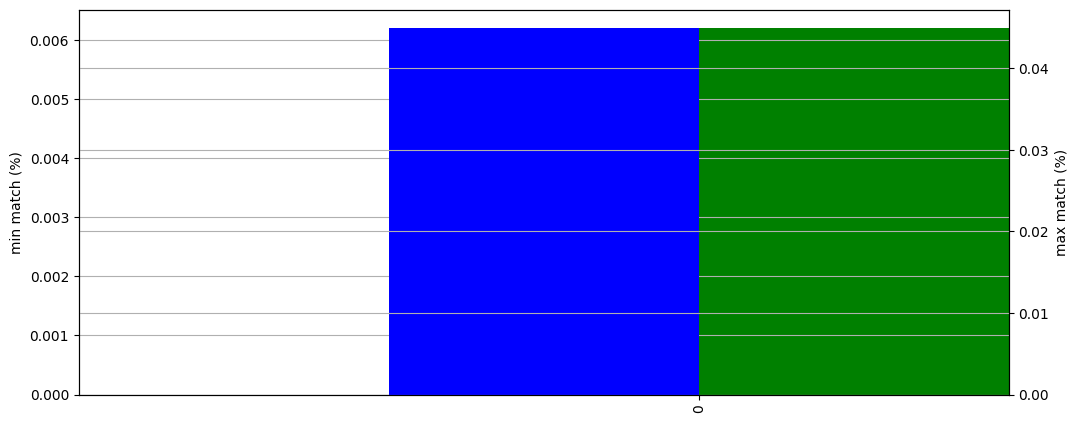

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(12, 5)) # Create matplotlib figure

ax1 = fig.add_subplot(111) # Create matplotlib axes
ax2 = ax1.twinx() # Create another axes that shares the same x-axis as a
width = .25

experiments_df['min_to_terminal_similarity'].plot(kind='bar', color='green', ax=ax1, width=width, position=0)
experiments_df['max_to_terminal_similarity'].plot(kind='bar', color='blue', ax=ax2, width=width, position=1)

ax1.set_ylabel('min match (%)')
ax2.set_ylabel('max match (%)')

ax1.grid(None, axis='y')
ax2.grid(None)

plt.show()

In [22]:
experiments_success_condition = experiments_df['max_to_terminal_similarity'] > experiments_df['min_to_terminal_similarity']
experiments_success_amount = len(experiments_df.loc[experiments_success_condition].values)

In [23]:
print(f'Success rate: {(experiments_success_amount / EXPERIMENTS) * 100}%')

Success rate: 100.0%
